In [1]:
import numpy as np 
import os 
import xarray as xr
import pandas as pd

from collections import OrderedDict
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as ticker
import matplotlib as mpl
from matplotlib import colors
from matplotlib import colormaps
import matplotlib.colors as mcolors
from matplotlib.colors import ListedColormap, LinearSegmentedColormap
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.pyplot import cm
import matplotlib
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from matplotlib.lines import Line2D
from matplotlib.legend_handler import HandlerBase
import matplotlib.patches as mpatches
from mpl_axes_aligner import align
import cmasher as cmr

import sys 
import re 
import yaml
import inspect 
from collections import defaultdict

In [2]:
dirpath = '/uufs/chpc.utah.edu/common/home/haskins-group1/users/vsun/USOS_shared/'

In [3]:
days_of_week = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
hour_range = np.arange(0,24,1)

In [4]:
ozone_filepath = dirpath + '/Plotting/USOS_Campaign_analysis/all_ozone_during_usos_with_exceedances.csv'

In [5]:
mpl.rcParams['xtick.labelsize'] = 15
mpl.rcParams['ytick.labelsize'] = 15
mpl.rcParams['legend.fontsize'] = 16
mpl.rcParams['axes.labelsize'] = 18
mpl.rcParams['axes.titlesize'] = 28
mpl.rcParams['axes.xmargin'] = 0

# Set the font family to 'serif'
mpl.rcParams['font.family'] = 'serif'
# Specify 'cmr10' as the preferred serif font (Computer Modern Roman)
mpl.rcParams['font.serif'] = 'cmr10' 
# Optionally, configure mathtext to use Computer Modern fonts as well
mpl.rcParams['mathtext.fontset'] = 'cm'
# Ensure minus signs are rendered correctly with CM fonts
mpl.rcParams['axes.unicode_minus'] = False

In [6]:
all_days_filepath = dirpath + 'CampaignData_and_Merges/R0/CSL_MobileLab_Parked/merged/rev_30min/all_CSL_MobileLab_Parked_rev30minv4.nc'
all_days_filepath_load = xr.open_dataset(all_days_filepath)
df_alldays = all_days_filepath_load.to_dataframe()
df_alldays.reset_index(inplace=True)
df_alldays.set_index('time_local', inplace=True, drop=False)

df_subsetdays_resample = df_alldays.resample('1h').mean()
#adds padding of NaNs for first day and last day of campaign, since they need to have the same length of time as the other days in order to plot
new_start_time = pd.Timestamp('2024-07-15 00:00:00')
new_end_time = pd.Timestamp('2024-08-18 23:00:00')
# Create a new datetime index from new_start to the end of existing index with same frequency
new_index = pd.date_range(start=new_start_time, end=new_end_time, freq='1h')
# Reindex the dataframe to include new rows
df_alldays = df_subsetdays_resample.reindex(new_index)

#add NO and NO2 to get NOx values
df_alldays['NOx_ppbv'] = df_alldays['NO_LIF'] + df_alldays['NO2_LIF']

In [7]:
month_index_allspecies = df_alldays.index.month
date_index_allspecies = df_alldays.index.date
day_names_index_allspecies = df_alldays.index.day_name()
hr_of_day_index_allspecies = df_alldays.index.time
weekday_index_allspecies = df_alldays.index.weekday
df_alldays['Weekday'] = np.where(weekday_index_allspecies < 5, 'Weekday', 'Weekend')
df_alldays['Sunday'] = np.where(weekday_index_allspecies == 6, 'Sunday', 'Not-Sunday')

# Ozone only

35
                     Mobile Lab O3  UDAQ O3  merged_ozone  \
dt                                                          
2024-07-15 00:00:00            NaN      NaN           NaN   
2024-07-15 01:00:00            NaN      NaN           NaN   
2024-07-15 02:00:00            NaN      NaN           NaN   
2024-07-15 03:00:00            NaN      NaN           NaN   
2024-07-15 04:00:00            NaN      NaN           NaN   
2024-07-15 05:00:00            NaN      NaN           NaN   
2024-07-15 06:00:00            NaN      NaN           NaN   
2024-07-15 07:00:00            NaN      NaN           NaN   
2024-07-15 08:00:00            NaN      NaN           NaN   
2024-07-15 09:00:00            NaN      NaN           NaN   
2024-07-15 10:00:00            NaN      NaN           NaN   
2024-07-15 11:00:00            NaN      NaN           NaN   
2024-07-15 12:00:00            NaN      NaN           NaN   
2024-07-15 13:00:00            NaN      NaN           NaN   
2024-07-15 14:00:00  

/tmp/ipykernel_3107485/863434574.py:26: UserWarning: cmr10 font should ideally be used with mathtext, set axes.formatter.use_mathtext to True
  fig, ax = plt.subplots(figsize=(10, 10))


                     Mobile Lab O3  UDAQ O3  merged_ozone  \
dt                                                          
2024-08-06 00:00:00      50.224056     50.0     50.224056   
2024-08-06 01:00:00      49.304722     49.0     49.304722   
2024-08-06 02:00:00      44.593056     43.0     44.593056   
2024-08-06 03:00:00      37.458722     37.0     37.458722   
2024-08-06 04:00:00      44.445889     44.0     44.445889   
2024-08-06 05:00:00      43.748056     43.0     43.748056   
2024-08-06 06:00:00      43.273222     42.0     43.273222   
2024-08-06 07:00:00      43.033722     42.0     43.033722   
2024-08-06 08:00:00      43.135889     42.0     43.135889   
2024-08-06 09:00:00      42.753556     42.0     42.753556   
2024-08-06 10:00:00      50.487631     52.0     50.487631   
2024-08-06 11:00:00      59.441294     59.0     59.441294   
2024-08-06 12:00:00      57.656056     55.0     57.656056   
2024-08-06 13:00:00      57.837056     58.0     57.837056   
2024-08-06 14:00:00     

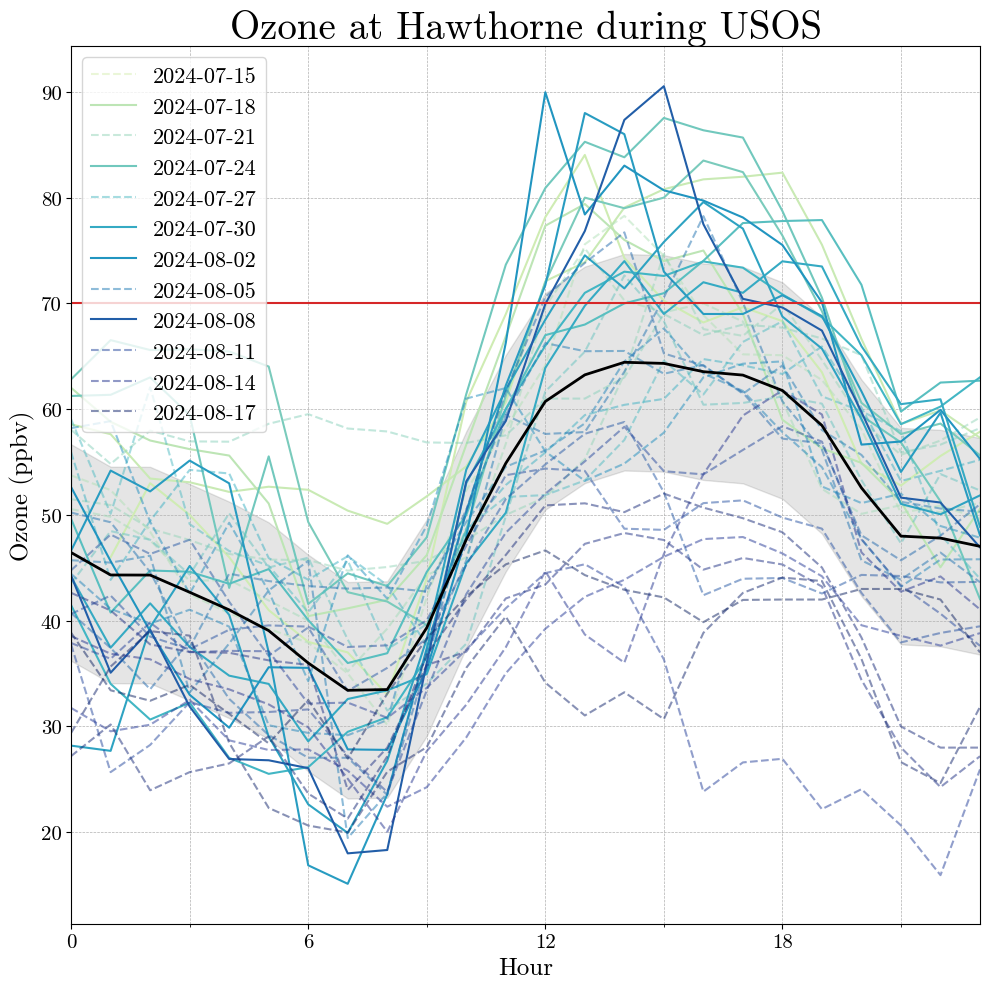

In [8]:
ozone_saved_filepath = dirpath + 'Plotting/USOS_Campaign_analysis/all_ozone_during_usos_with_exceedances.csv'
df_ozone = pd.read_csv(ozone_saved_filepath, index_col='dt', parse_dates=True)

month_index_ozone = df_ozone.index.month
date_index_ozone = df_ozone.index.date
day_names_index_ozone =df_ozone.index.day_name()
hr_of_day_index_ozone = df_ozone.index.time
weekday_index_ozone = df_ozone.index.weekday
df_ozone['Weekday'] = np.where(weekday_index_ozone < 5, 'Weekday', 'Weekend')
df_ozone['Sunday'] = np.where(weekday_index_ozone == 6, 'Sunday', 'Not-Sunday')

overall_ozone_avg = df_ozone['merged_ozone'].groupby([hr_of_day_index_ozone]).mean()
overall_ozone_std = np.std(overall_ozone_avg)

overall_dates = pd.date_range(start='2024-07-15', end='2024-08-18')
overall_dates_list = overall_dates.strftime('%Y-%m-%d')

color_values = np.linspace(0.2, 1, 36) 
cmap1 = mpl.colormaps['YlGnBu']

# Get unique days
unique_days = df_ozone.index.normalize().unique()
num_days = len(unique_days)
print(len(unique_days))

fig, ax = plt.subplots(figsize=(10, 10))
for i, day in enumerate(unique_days):
    mask = df_ozone.index.normalize() == day
    day_df = df_ozone[mask]
    print(day_df)
    # print(df_ozone.index.date)
    # print(day)
    # day_df = df_ozone[df_ozone.index.date == day]
    # print(day_df)
    #x = day_df.index.hour
    dashed_linestyle = '-' if day_df['Exceedance_day_merged_ozone'].any() else '--'
    alpha_amount = 1 if day_df['Exceedance_day_merged_ozone'].any() else 0.5
    label = str(day.date()) if i % 3 == 0 else None  # label every 3rd day, else no label
    plt.plot(hour_range, day_df['merged_ozone'], linestyle=dashed_linestyle, color=cmap1(color_values[i]), label=label, alpha = alpha_amount)

ax.xaxis.set_minor_locator(MultipleLocator(3))
ax.xaxis.set_major_locator(MultipleLocator(6))
plt.plot(hour_range,overall_ozone_avg, linestyle='solid', linewidth=2, color='k')
plt.fill_between(hour_range, overall_ozone_avg - overall_ozone_std, overall_ozone_avg + overall_ozone_std, color='k',alpha = 0.1)
plt.hlines(y=70, xmin = 0, xmax = 23, color = 'tab:red')
# plt.xticks(np.arange(0,24,1))
plt.xlabel('Hour')
plt.ylabel('Ozone (ppbv)')
plt.title('Ozone at Hawthorne during USOS')
plt.legend()
plt.margins(x=0)
#plt.grid()
ax.grid(which='both', linestyle='--', linewidth=0.5)

plt.tight_layout()

true_count = df_ozone['Exceedance_day_merged_ozone'].sum()
print(true_count)
print(len(df_ozone.index))

dt
2024-07-15 00:00:00    False
2024-07-15 01:00:00    False
2024-07-15 02:00:00    False
2024-07-15 03:00:00    False
2024-07-15 04:00:00    False
                       ...  
2024-08-18 19:00:00    False
2024-08-18 20:00:00    False
2024-08-18 21:00:00    False
2024-08-18 22:00:00    False
2024-08-18 23:00:00    False
Name: Exceedance_day_Mobile Lab O3, Length: 840, dtype: bool
35


/tmp/ipykernel_3107485/2213090043.py:19: UserWarning: cmr10 font should ideally be used with mathtext, set axes.formatter.use_mathtext to True
  fig, ax = plt.subplots(figsize=(10, 10), layout = 'tight')


Exceedance days during USOS:  9  out of  33  days of ozone measurements (2024-07-14 to 2024-08-18)


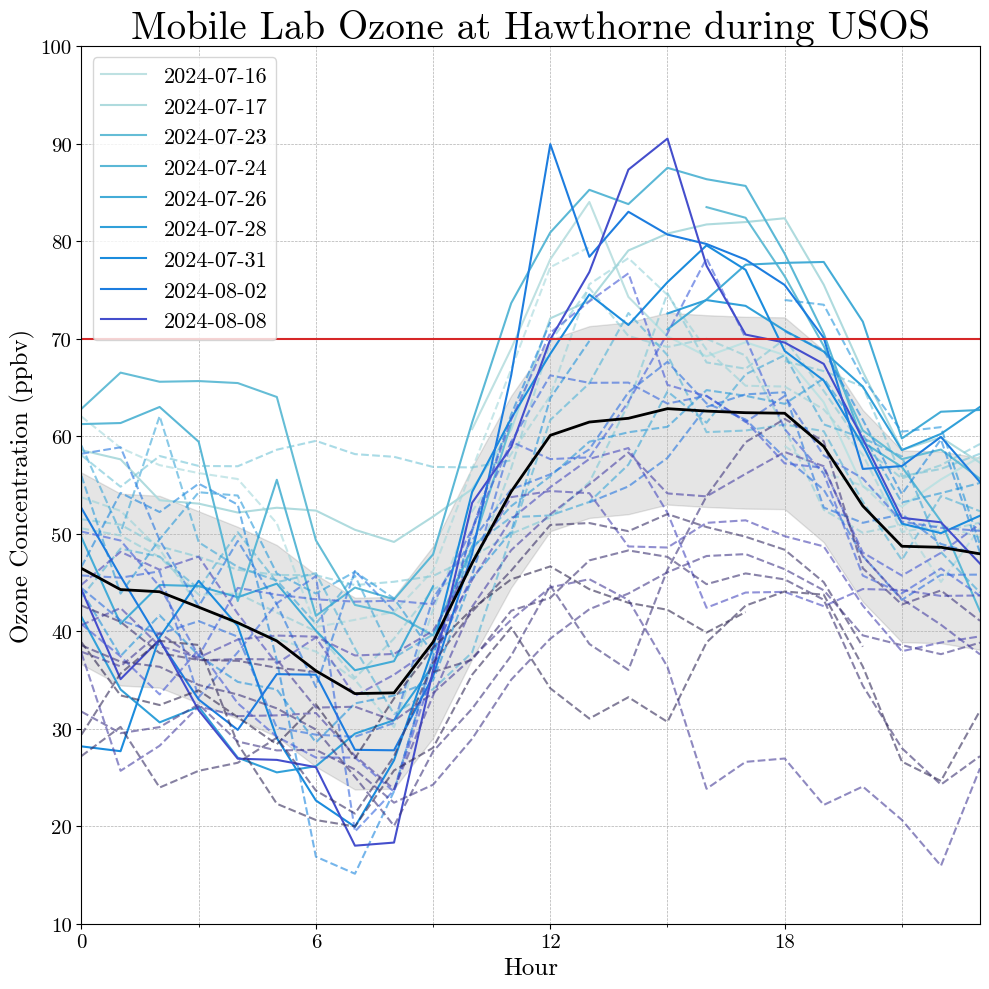

In [30]:
ozone_saved_filepath = dirpath + 'Plotting/USOS_Campaign_analysis/all_ozone_during_usos_with_exceedances.csv'
df_ozone = pd.read_csv(ozone_saved_filepath, index_col='dt', parse_dates=True)

month_index_ozone = df_ozone.index.month
date_index_ozone = df_ozone.index.date
day_names_index_ozone =df_ozone.index.day_name()
hr_of_day_index_ozone = df_ozone.index.time

overall_ozone_avg = df_ozone['Mobile Lab O3'].groupby([hr_of_day_index_ozone]).mean()
overall_ozone_std = np.std(overall_ozone_avg)

overall_dates = pd.date_range(start='2024-07-15', end='2024-08-18')
overall_dates_list = overall_dates.strftime('%Y-%m-%d')

# Get number of days in the campaign
unique_days = df_ozone.index.normalize().unique()
num_days = len(unique_days)
print(df_ozone['Exceedance_day_Mobile Lab O3'])
fig, ax = plt.subplots(figsize=(10, 10), layout = 'tight')
colors = cmr.take_cmap_colors('cmr.freeze_r', 35, cmap_range=(0.1, 0.8), return_fmt='hex')
print(len(colors))
for i, day in enumerate(unique_days):
    mask = df_ozone.index.normalize() == day
    day_df = df_ozone[mask]
    dashed_linestyle = '-' if day_df['Exceedance_day_Mobile Lab O3'].any() else '--'
    alpha_amount = 1 if day_df['Exceedance_day_Mobile Lab O3'].any() else 0.6
    exceedance_labels = str(day.date()) if day_df['Exceedance_day_Mobile Lab O3'].any() else '_'
    #label = str(day.date()) if i % 3 == 0 else None  # label every 3rd day, else no label
    plt.plot(hour_range, day_df['Mobile Lab O3'], linestyle=dashed_linestyle, color=colors[i], label=exceedance_labels, alpha = alpha_amount)

plt.plot(hour_range,overall_ozone_avg, linestyle='solid', linewidth=2, color='k')
plt.fill_between(hour_range, overall_ozone_avg - overall_ozone_std, overall_ozone_avg + overall_ozone_std, color='k',alpha = 0.1)
plt.hlines(y=70, xmin = 0, xmax = 23, color = 'tab:red')

plt.xlabel('Hour')
ax.xaxis.set_minor_locator(MultipleLocator(3))
ax.xaxis.set_major_locator(MultipleLocator(6))
plt.xticks()
plt.margins(x=0)
plt.ylim([10,100])

plt.ylabel('Ozone Concentration (ppbv)')
plt.title('Mobile Lab Ozone at Hawthorne during USOS')

# box = ax.get_position()
# ax.set_position([box.x0, box.y0, box.width * 0.8, box.height])
ax.legend(loc='upper left')#, bbox_to_anchor=(1, 0.5))

#add grid
ax.grid(which='both', linestyle='--', linewidth=0.5)

plt.savefig(dirpath + '/Plotting/USOS_Campaign_analysis/plots/ozone_mixing_ratio_usos.png', dpi =150)

true_count = df_ozone['Exceedance_day_Mobile Lab O3'].sum()
print('Exceedance days during USOS: ', int(true_count/24), ' out of ', int(len(df_ozone.index)/24)-2, ' days of ozone measurements (2024-07-14 to 2024-08-18)')

# NOx and Ozone together

In [ ]:
all_days_filepath = dirpath + 'CampaignData_and_Merges/R0/CSL_MobileLab_Parked/merged/rev_30min/all_CSL_MobileLab_Parked_rev30minv4.nc'
all_days_filepath_load = xr.open_dataset(all_days_filepath)
df_alldays = all_days_filepath_load.to_dataframe()
df_alldays.reset_index(inplace=True)
df_alldays.set_index('time_local', inplace=True, drop=False)

df_subsetdays_resample = df_alldays.resample('1h').mean()

#adds padding of NaNs for first day and last day of campaign, since they need to have the same length of time as the other days in order to plot
new_start_time = pd.Timestamp('2024-07-15 00:00:00')
new_end_time = pd.Timestamp('2024-08-18 23:00:00')
# Create a new datetime index from new_start to the end of existing index with same frequency
new_index = pd.date_range(start=new_start_time, end=new_end_time, freq='1h')
# Reindex the dataframe to include new rows
df_alldays = df_subsetdays_resample.reindex(new_index)

#add NO and NO2 to get NOx values
df_alldays['NOx_ppbv'] = df_alldays['NO_LIF'] + df_alldays['NO2_LIF']
month_index_allspecies = df_alldays.index.month
date_index_allspecies = df_alldays.index.date
day_names_index_allspecies = df_alldays.index.day_name()
hr_of_day_index_allspecies = df_alldays.index.time

In [ ]:
ozone_saved_filepath = dirpath + 'Plotting/USOS_Campaign_analysis/all_ozone_during_usos_with_exceedances.csv'
df_ozone = pd.read_csv(ozone_saved_filepath, index_col='dt', parse_dates=True)
overall_ozone_avg_merged = df_ozone['merged_ozone'].groupby([hr_of_day_index_ozone]).mean()
overall_ozone_std_merged = np.std(overall_ozone_avg_merged)
overall_ozone_avg_usos_nomerge = df_ozone['USOS O3'].groupby([hr_of_day_index_ozone]).mean()
overall_ozone_std_usos_nomerge = np.std(overall_ozone_avg_usos_nomerge)

overall_dates = pd.date_range(start='2024-07-15', end='2024-08-18')
overall_dates_list = overall_dates.strftime('%Y-%m-%d')

# Get unique days
unique_days = df_ozone.index.normalize().unique()
num_days = len(unique_days)
print(len(unique_days))


35


In [ ]:
df_ozone['merged_ozone']

dt
2024-07-15 00:00:00     NaN
2024-07-15 01:00:00     NaN
2024-07-15 02:00:00     NaN
2024-07-15 03:00:00     NaN
2024-07-15 04:00:00     NaN
                       ... 
2024-08-18 19:00:00    43.0
2024-08-18 20:00:00    43.0
2024-08-18 21:00:00    42.0
2024-08-18 22:00:00    37.0
2024-08-18 23:00:00    28.0
Name: merged_ozone, Length: 840, dtype: float64

In [ ]:
species_var1 = 'NOx_ppbv'
species_var2 = 'merged_ozone'
species_name1 = 'NOx'
species_name2 = 'Ozone'
y_limit1 = [0,40]
y_limit2 = [10,100]
# y_ticks1 = np.arange(0,40,5)
# y_ticks2 = np.arange(10,100,5)
color_map1 = 'YlGnBu_r'
color_map2 = 'YlOrRd_r'
plot_name = 'nox_ozone_usos.png'

df_nox = df_alldays[species_var1]
overall_nox_avg = df_nox.groupby([hr_of_day_index_allspecies]).mean()
overall_nox_std = np.std(overall_nox_avg)


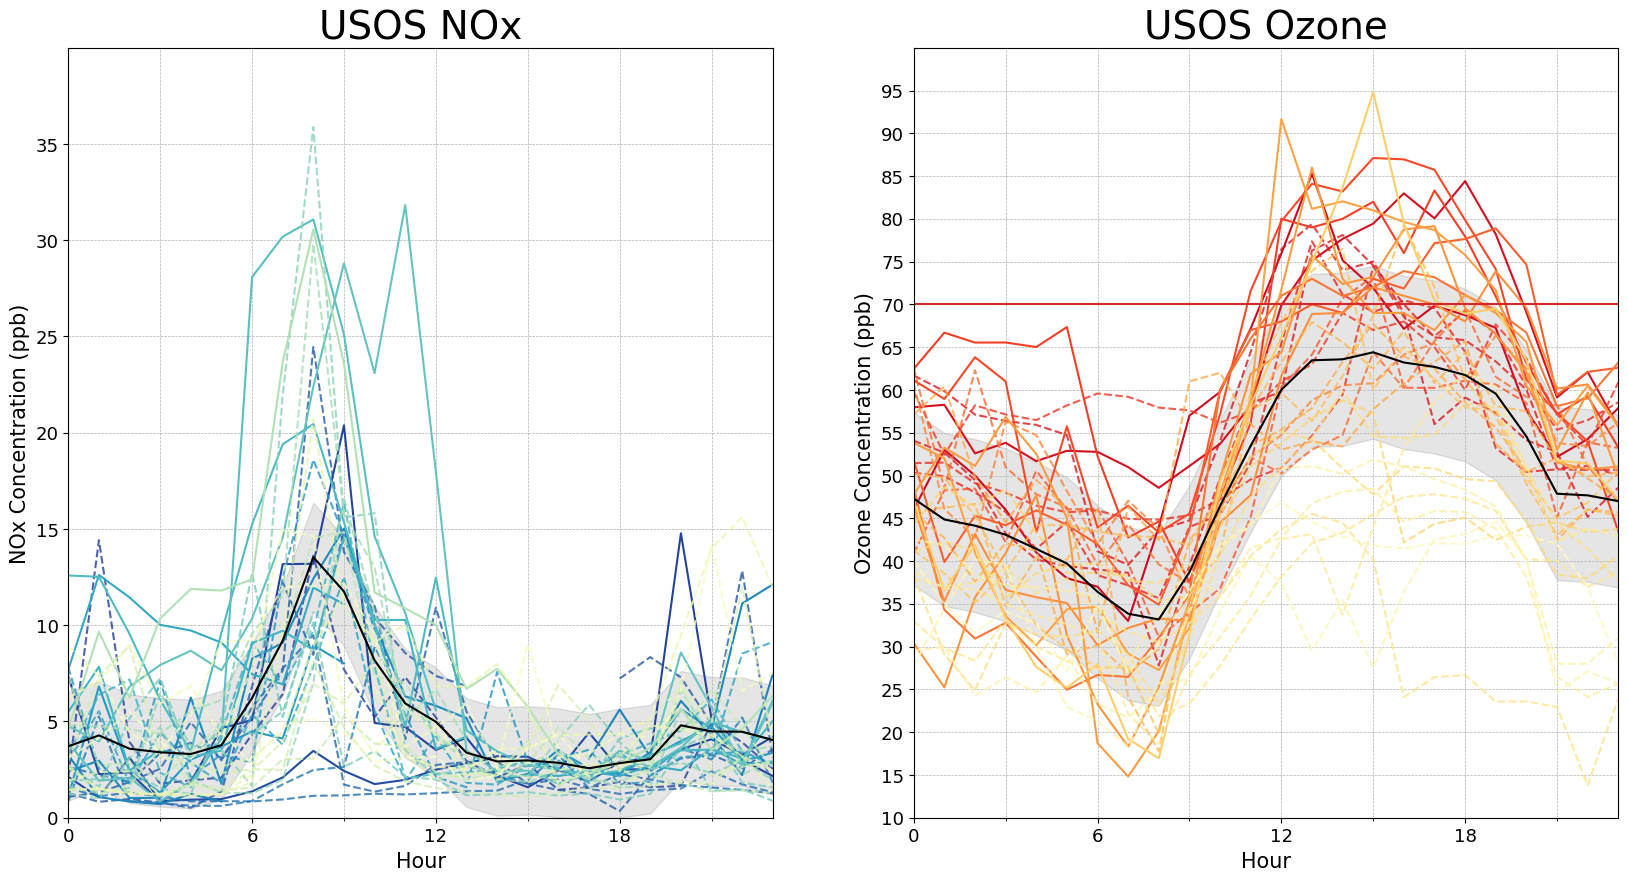

In [ ]:
fig, ax = plt.subplots(1,2, figsize = (20,10))

# Create 20 color values for gradient in the colormap
color_values = np.linspace(0.15, 0.95, 35) 
cmap1 = mpl.colormaps[color_map1]
cmap2 = mpl.colormaps[color_map2]


for i, day in enumerate(unique_days):
    mask = df_ozone.index.normalize() == day
    day_df_o3 = df_ozone[mask]
    #print(day_df['merged_ozone'])
    day_df_nox = (df_nox[mask])
    #print(day_df_nox)
    # print(df_ozone.index.date)
    # print(day)
    # day_df = df_ozone[df_ozone.index.date == day]
    # print(day_df)
    #x = day_df.index.hour
    dashed_linestyle = '-' if day_df_o3['Exceedance_day_merged_ozone'].any() else '--'
    alpha_amount = 1 if day_df_o3['Exceedance_day_merged_ozone'].any() else 0.8
    exceedance_labels = str(day.date()) if day_df_o3['Exceedance_day_merged_ozone'].any() else '_'
    #label = str(day.date()) if i % 3 == 0 else None  # label every 3rd day, else no label
    ax[0].plot(hour_range, day_df_nox, linestyle=dashed_linestyle, color=cmap1(color_values[i]), label=exceedance_labels, alpha = alpha_amount)
    ax[0].set_xlabel('Hour')
    ax[0].set_ylabel(species_name1 + ' Concentration (ppb)')
    ax[0].set_xticks(np.arange(0,24))
    ax[0].set_ylim(y_limit1)
    ax[0].set_yticks(y_ticks1)
    ax[0].set_title('USOS ' + species_name1)
    
    ax[1].plot(hour_range, day_df_o3['merged_ozone'], linestyle=dashed_linestyle, color=cmap2(color_values[i]), label=exceedance_labels, alpha = alpha_amount)
    ax[1].set_xlabel('Hour')
    ax[1].set_ylabel(species_name2 + ' Concentration (ppb)')
    ax[1].set_xticks(np.arange(0,24))
    ax[1].set_ylim(y_limit2)
    ax[1].set_yticks(y_ticks2)
    ax[1].set_title('USOS ' + species_name2)
ax[0].plot(hour_range, overall_nox_avg, color = 'k', label = 'Campaign Average')
ax[0].fill_between(hour_range, overall_nox_avg - overall_nox_std, overall_nox_avg + overall_nox_std, color='k',alpha = 0.1)
ax[0].xaxis.set_minor_locator(MultipleLocator(3))
ax[0].xaxis.set_major_locator(MultipleLocator(6))
ax[0].grid(which='both', linestyle='--', linewidth=0.5)

ax[1].plot(hour_range, overall_ozone_avg, color = 'k', label = 'Campaign Average')
ax[1].fill_between(hour_range, overall_ozone_avg_merged - overall_ozone_std_merged, overall_ozone_avg_merged + overall_ozone_std_merged, color='k',alpha = 0.1)
ax[1].xaxis.set_minor_locator(MultipleLocator(3))
ax[1].xaxis.set_major_locator(MultipleLocator(6))
ax[1].grid(which='both', linestyle='--', linewidth=0.5)
ax[1].hlines(y=70, xmin = 0, xmax = 23, color = 'tab:red')

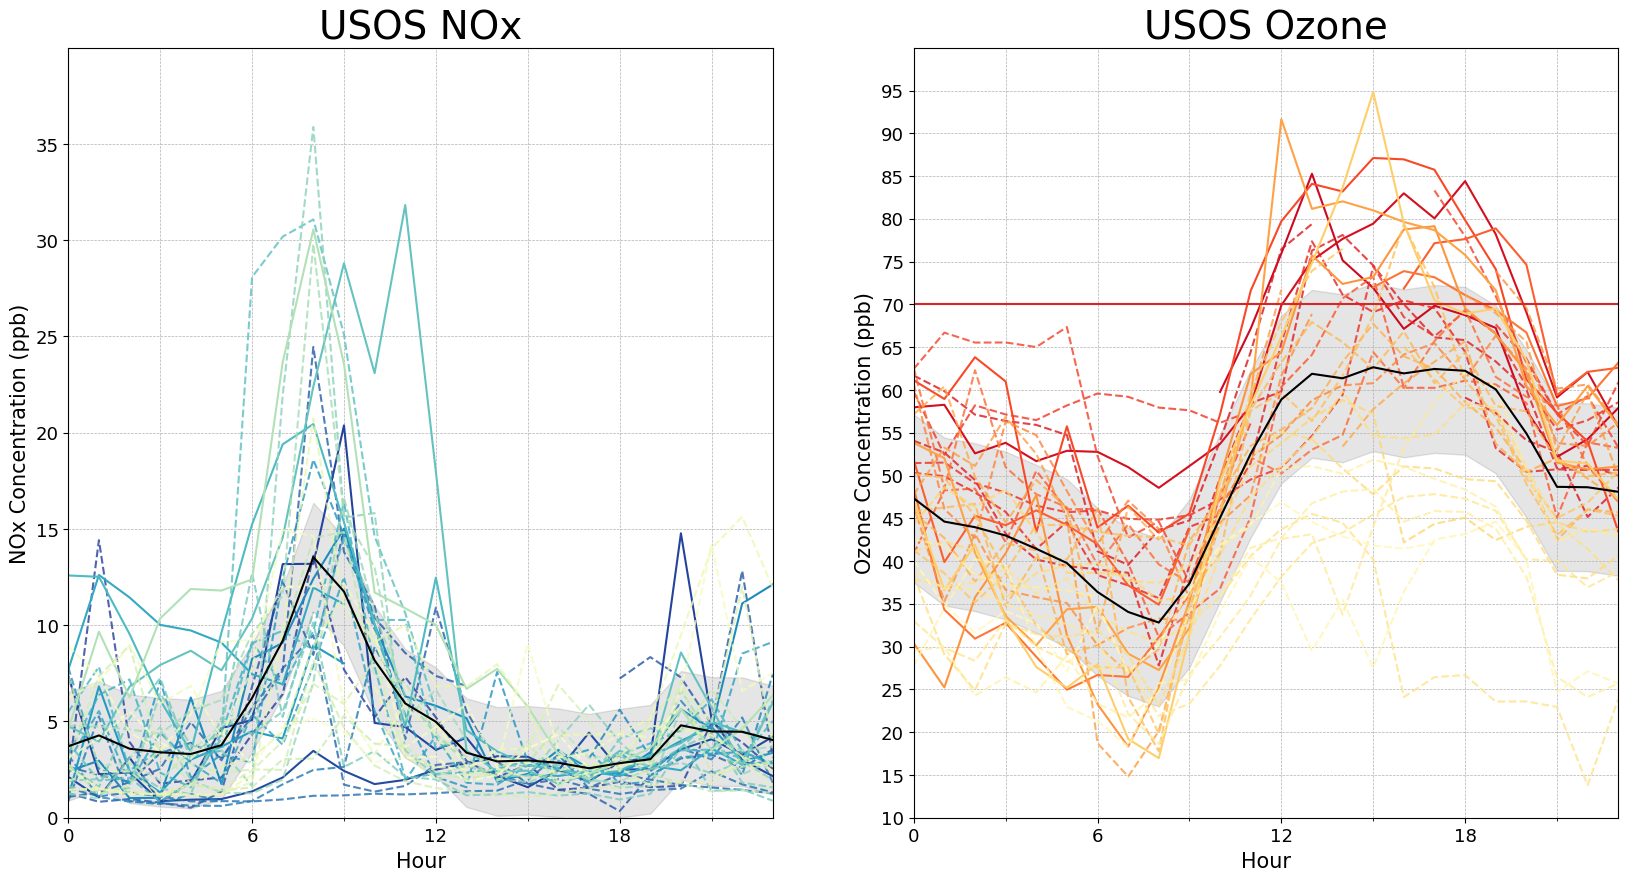

In [ ]:
fig, ax = plt.subplots(1,2, figsize = (20,10))

# Create color values for gradient in the colormap
color_values = np.linspace(0.15, 0.95, 35) 
cmap1 = mpl.colormaps[color_map1]
cmap2 = mpl.colormaps[color_map2]

for i, day in enumerate(unique_days):
    mask = df_ozone.index.normalize() == day
    day_df_o3 = df_ozone[mask]
    #print(day_df['merged_ozone'])
    day_df_nox = (df_nox[mask])
    #print(day_df_nox)
    # print(df_ozone.index.date)
    # print(day)
    # day_df = df_ozone[df_ozone.index.date == day]
    # print(day_df)
    #x = day_df.index.hour
    dashed_linestyle = '-' if day_df_o3['Exceedance_day_USOS O3'].any() else '--'
    alpha_amount = 1 if day_df_o3['Exceedance_day_USOS O3'].any() else 0.8
    exceedance_labels = str(day.date()) if day_df_o3['Exceedance_day_USOS O3'].any() else '_'
    #label = str(day.date()) if i % 3 == 0 else None  # label every 3rd day, else no label
    ax[0].plot(hour_range, day_df_nox, linestyle=dashed_linestyle, color=cmap1(color_values[i]), label=exceedance_labels, alpha = alpha_amount)
    ax[0].set_xlabel('Hour')
    ax[0].set_ylabel(species_name1 + ' Concentration (ppb)')
    ax[0].set_ylim(y_limit1)
    #ax[0].set_yticks(y_ticks1)
    ax[0].set_title('USOS ' + species_name1)
    
    ax[1].plot(hour_range, day_df_o3['USOS O3'], linestyle=dashed_linestyle, color=cmap2(color_values[i]), label=exceedance_labels, alpha = alpha_amount)
    ax[1].set_xlabel('Hour')
    ax[1].set_ylabel(species_name2 + ' Concentration (ppb)')
    ax[1].set_ylim(y_limit2)
    #ax[1].set_yticks(y_ticks2)
    ax[1].set_title('USOS ' + species_name2)
ax[0].plot(hour_range, overall_nox_avg, color = 'k', label = 'Campaign Average')
ax[0].fill_between(hour_range, overall_nox_avg - overall_nox_std, overall_nox_avg + overall_nox_std, color='k',alpha = 0.1)
ax[0].xaxis.set_minor_locator(MultipleLocator(3))
ax[0].xaxis.set_major_locator(MultipleLocator(6))
ax[0].grid(which='both', linestyle='--', linewidth=0.5)

ax[1].plot(hour_range, overall_ozone_avg_usos_nomerge, color = 'k', label = 'Campaign Average')
ax[1].fill_between(hour_range, overall_ozone_avg_usos_nomerge - overall_ozone_std_usos_nomerge, overall_ozone_avg_usos_nomerge + overall_ozone_std_usos_nomerge, color='k',alpha = 0.1)
ax[1].xaxis.set_minor_locator(MultipleLocator(3))
ax[1].xaxis.set_major_locator(MultipleLocator(6))
ax[1].grid(which='both', linestyle='--', linewidth=0.5)
ax[1].hlines(y=70, xmin = 0, xmax = 23, color = 'tab:red')

## Weekend and Weekday Comparison

In [ ]:
day_of_week_ozone_mean = df_ozone.groupby([day_names_index_ozone, hr_of_day_index_ozone])['merged_ozone'].mean()
day_of_week_allspecies_mean = df_alldays.groupby([day_names_index_allspecies, hr_of_day_index_allspecies])['NOx_ppbv'].mean()

weekday_ozone_mean = df_ozone.groupby(['Weekday', hr_of_day_index_ozone])['merged_ozone'].mean()
weekday_allspecies_mean = df_alldays.groupby(['Weekday', hr_of_day_index_allspecies])['NOx_ppbv'].mean()

weekday_type_list = ['Weekday', 'Weekend']
weekday_type_list_sunday = ['Weekday','Sunday']

y_limit1_weekend = [0,30]
y_limit2_weekend = [20,80]

In [ ]:
print(weekday_allspecies_mean['Weekday'])

00:00:00     3.707162
01:00:00     4.179369
02:00:00     3.232371
03:00:00     3.114181
04:00:00     3.208311
05:00:00     3.600147
06:00:00     6.623759
07:00:00    10.920314
08:00:00    15.958117
09:00:00    13.928799
10:00:00     9.688930
11:00:00     7.164416
12:00:00     5.793308
13:00:00     3.791205
14:00:00     3.407785
15:00:00     2.946827
16:00:00     3.036902
17:00:00     2.859401
18:00:00     3.023851
19:00:00     3.224403
20:00:00     5.141878
21:00:00     4.511684
22:00:00     4.821701
23:00:00     4.296595
Name: NOx_ppbv, dtype: float64


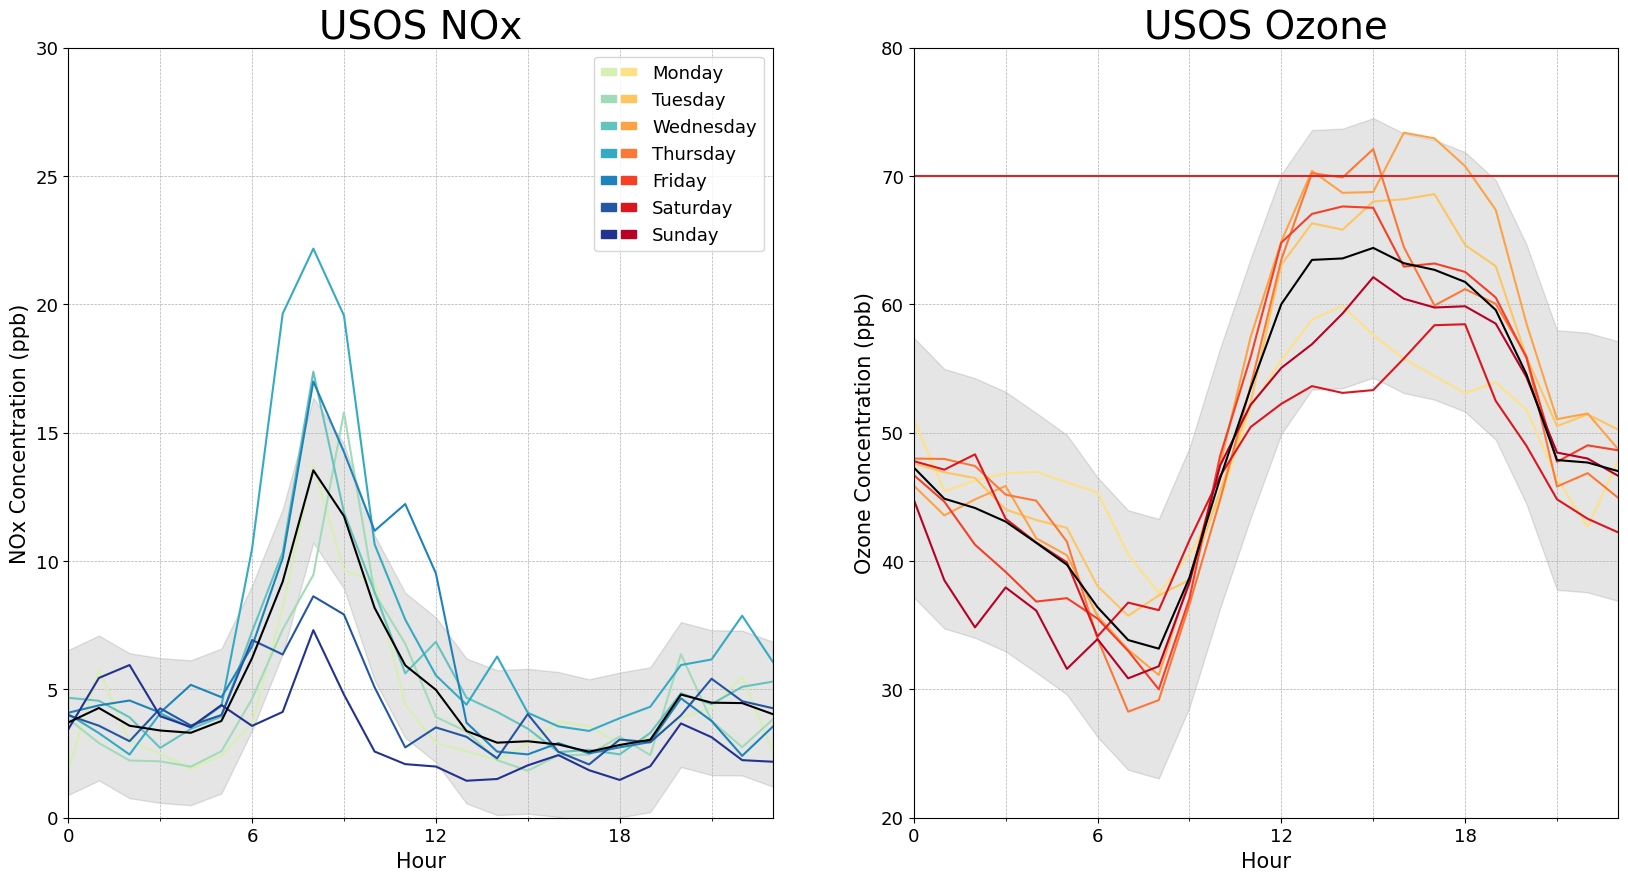

In [ ]:
fig, ax = plt.subplots(1,2, figsize = (20,10))

# Create 20 color values for gradient in the colormap
color_values_week = np.linspace(0.2, 1, 8)
color_map1 = 'YlGnBu'
color_map2 = 'YlOrRd'
cmap1 = mpl.colormaps[color_map1]
cmap2 = mpl.colormaps[color_map2]

class TwoColorHandler(HandlerBase):
       def create_artists(self, legend, orig_handle,
                       xdescent, ydescent, width, height, fontsize, trans):
        patch_width = width / 2.5  # width of each square
        patch_height = height * 0.6  # height of each square
        spacing = 4
        y = ydescent + (height - patch_height) / 2

        # Two colored rectangles side by side
        patch1 = mpatches.Rectangle((xdescent, y), patch_width, patch_height,
                                    facecolor=orig_handle[0], edgecolor=orig_handle[0], transform=trans)
        patch2 = mpatches.Rectangle((xdescent + patch_width + spacing, y), patch_width, patch_height,
                                    facecolor=orig_handle[1], edgecolor=orig_handle[1], transform=trans)

        return [patch1, patch2]
legend_handles = []
legend_labels = []

for day_val in range(0,7):
        ax[0].set_xlabel('Hour')
        ax[0].set_ylabel(species_name1 + ' Concentration (ppb)')
        ax[0].set_xticks(np.arange(0,24))
        ax[0].set_ylim(y_limit1_weekend)
        ax[0].set_title('USOS ' + species_name1)
        ax[0].plot(hour_range, day_of_week_allspecies_mean[days_of_week[day_val]], color=cmap1(color_values_week[day_val]), label = days_of_week[day_val])

        ax[1].plot(hour_range, day_of_week_ozone_mean[days_of_week[day_val]], color=cmap2(color_values_week[day_val]), label = days_of_week[day_val])
        ax[1].set_xlabel('Hour')
        ax[1].set_ylabel(species_name2 + ' Concentration (ppb)')
        ax[1].set_ylim(y_limit2_weekend)
        ax[1].set_title('USOS ' + species_name2)

        # Create dummy handle with two colors
        
        legend_handles.append((cmap1(color_values_week[day_val]), cmap2(color_values_week[day_val])))
        legend_labels.append(days_of_week[day_val])

        # Add to legend
        ax[0].legend(legend_handles, legend_labels, handler_map={tuple: TwoColorHandler()})

        # Create two small colored markers for one label

ax[0].plot(hour_range, overall_nox_avg, color = 'k', label = 'Campaign Average')
ax[0].fill_between(hour_range, overall_nox_avg - overall_nox_std, overall_nox_avg + overall_nox_std, color='k',alpha = 0.1)
ax[0].xaxis.set_minor_locator(MultipleLocator(3))
ax[0].xaxis.set_major_locator(MultipleLocator(6))
ax[0].grid(which='both', linestyle='--', linewidth=0.5)


# box = ax[0].get_position()
# ax[0].set_position([box.x0, box.y0, box.width * 0.8, box.height])
#ax[0].legend(loc='center left', bbox_to_anchor=(1, 0.5))

ax[1].plot(hour_range, overall_ozone_avg, color = 'k', label = 'Campaign Average')
ax[1].fill_between(hour_range, overall_ozone_avg_merged - overall_ozone_std_merged, overall_ozone_avg_merged + overall_ozone_std_merged, color='k',alpha = 0.1)
ax[1].xaxis.set_minor_locator(MultipleLocator(3))
ax[1].xaxis.set_major_locator(MultipleLocator(6))
ax[1].grid(which='both', linestyle='--', linewidth=0.5)
ax[1].hlines(y=70, xmin = 0, xmax = 23, color = 'tab:red')

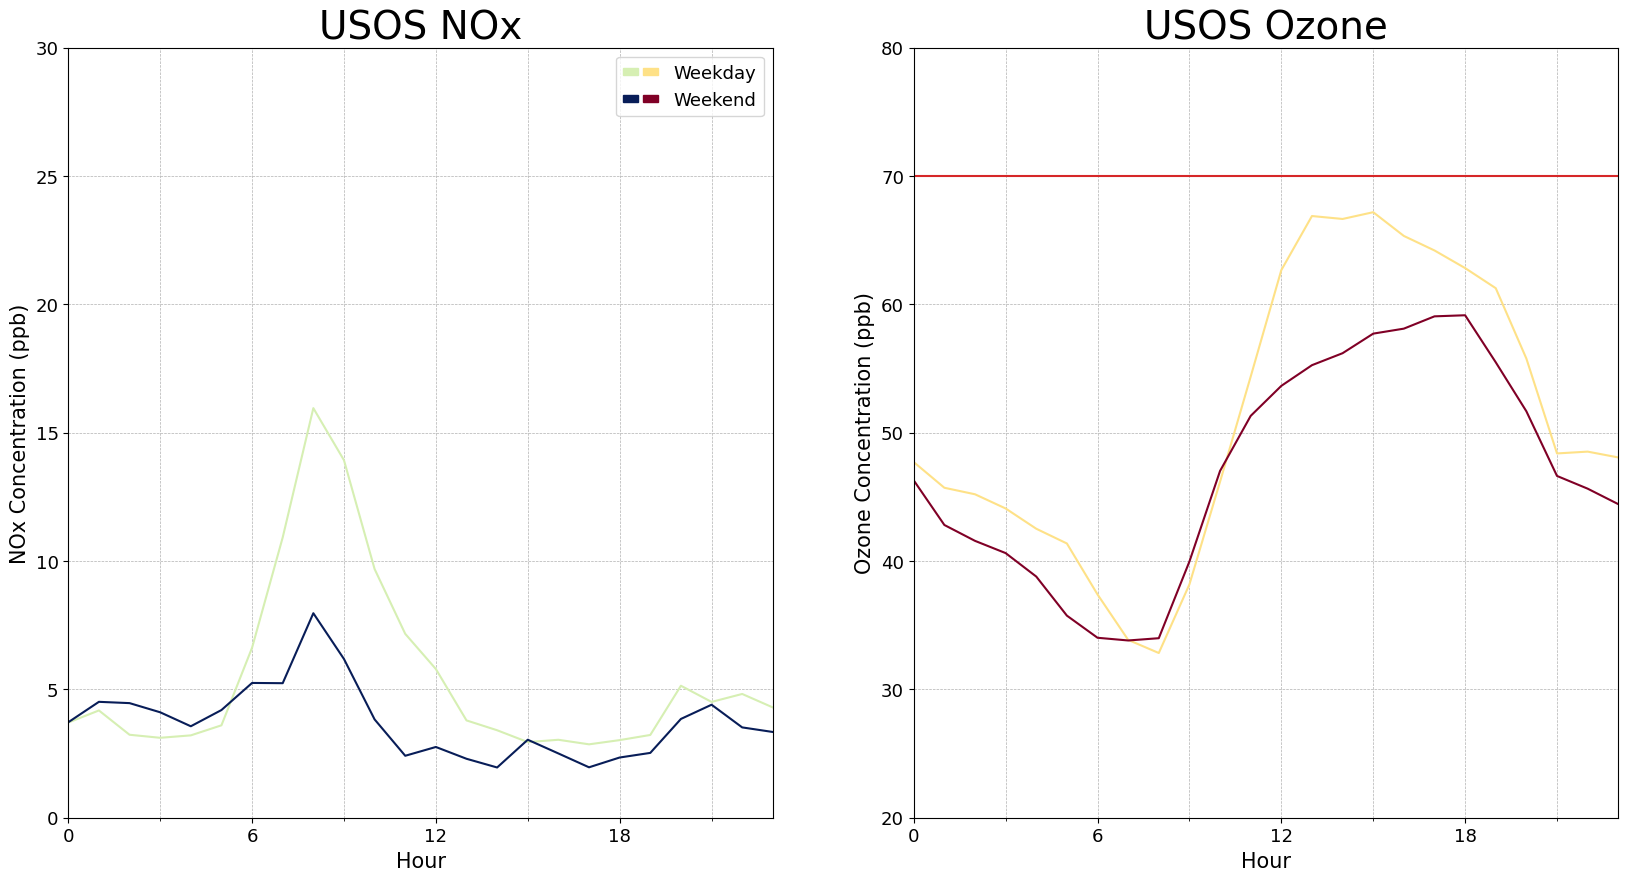

In [ ]:
fig, ax = plt.subplots(1,2, figsize = (20,10))

# Create 20 color values for gradient in the colormap
color_values_week = np.linspace(0.2, 1, 2)
color_map1 = 'YlGnBu'
color_map2 = 'YlOrRd'
cmap1 = mpl.colormaps[color_map1]
cmap2 = mpl.colormaps[color_map2]

class TwoColorHandler(HandlerBase):
       def create_artists(self, legend, orig_handle,
                       xdescent, ydescent, width, height, fontsize, trans):
        patch_width = width / 2.5  # width of each square
        patch_height = height * 0.6  # height of each square
        spacing = 4
        y = ydescent + (height - patch_height) / 2

        # Two colored rectangles side by side
        patch1 = mpatches.Rectangle((xdescent, y), patch_width, patch_height,
                                    facecolor=orig_handle[0], edgecolor=orig_handle[0], transform=trans)
        patch2 = mpatches.Rectangle((xdescent + patch_width + spacing, y), patch_width, patch_height,
                                    facecolor=orig_handle[1], edgecolor=orig_handle[1], transform=trans)

        return [patch1, patch2]
legend_handles = []
legend_labels = []

for day_val in range(0,2):
        ax[0].set_xlabel('Hour')
        ax[0].set_ylabel(species_name1 + ' Concentration (ppb)')
        ax[0].set_xticks(np.arange(0,24))
        ax[0].set_ylim(y_limit1_weekend)
        ax[0].set_title('USOS ' + species_name1)
        ax[0].plot(hour_range, weekday_allspecies_mean[weekday_type_list[day_val]], color=cmap1(color_values_week[day_val]), label = days_of_week[day_val])

        ax[1].plot(hour_range, weekday_ozone_mean[weekday_type_list[day_val]], color=cmap2(color_values_week[day_val]), label = days_of_week[day_val])
        ax[1].set_xlabel('Hour')
        ax[1].set_ylabel(species_name2 + ' Concentration (ppb)')
        ax[1].set_ylim(y_limit2_weekend)
        ax[1].set_title('USOS ' + species_name2)

        # Create dummy handle with two colors
        
        legend_handles.append((cmap1(color_values_week[day_val]), cmap2(color_values_week[day_val])))
        legend_labels.append(weekday_type_list[day_val])

        # Add to legend
        ax[0].legend(legend_handles, legend_labels, handler_map={tuple: TwoColorHandler()})

        # Create two small colored markers for one label

# ax[0].plot(hour_range, overall_nox_avg, color = 'k', label = 'Campaign Average')
# ax[0].fill_between(hour_range, overall_nox_avg - overall_nox_std, overall_nox_avg + overall_nox_std, color='k',alpha = 0.1)
ax[0].xaxis.set_minor_locator(MultipleLocator(3))
ax[0].xaxis.set_major_locator(MultipleLocator(6))
ax[0].grid(which='both', linestyle='--', linewidth=0.5)


# box = ax[0].get_position()
# ax[0].set_position([box.x0, box.y0, box.width * 0.8, box.height])
#ax[0].legend(loc='center left', bbox_to_anchor=(1, 0.5))

# ax[1].plot(hour_range, overall_ozone_avg, color = 'k', label = 'Campaign Average')
# ax[1].fill_between(hour_range, overall_ozone_avg_merged - overall_ozone_std_merged, overall_ozone_avg_merged + overall_ozone_std_merged, color='k',alpha = 0.1)
ax[1].xaxis.set_minor_locator(MultipleLocator(3))
ax[1].xaxis.set_major_locator(MultipleLocator(6))
ax[1].grid(which='both', linestyle='--', linewidth=0.5)
ax[1].hlines(y=70, xmin = 0, xmax = 23, color = 'tab:red')

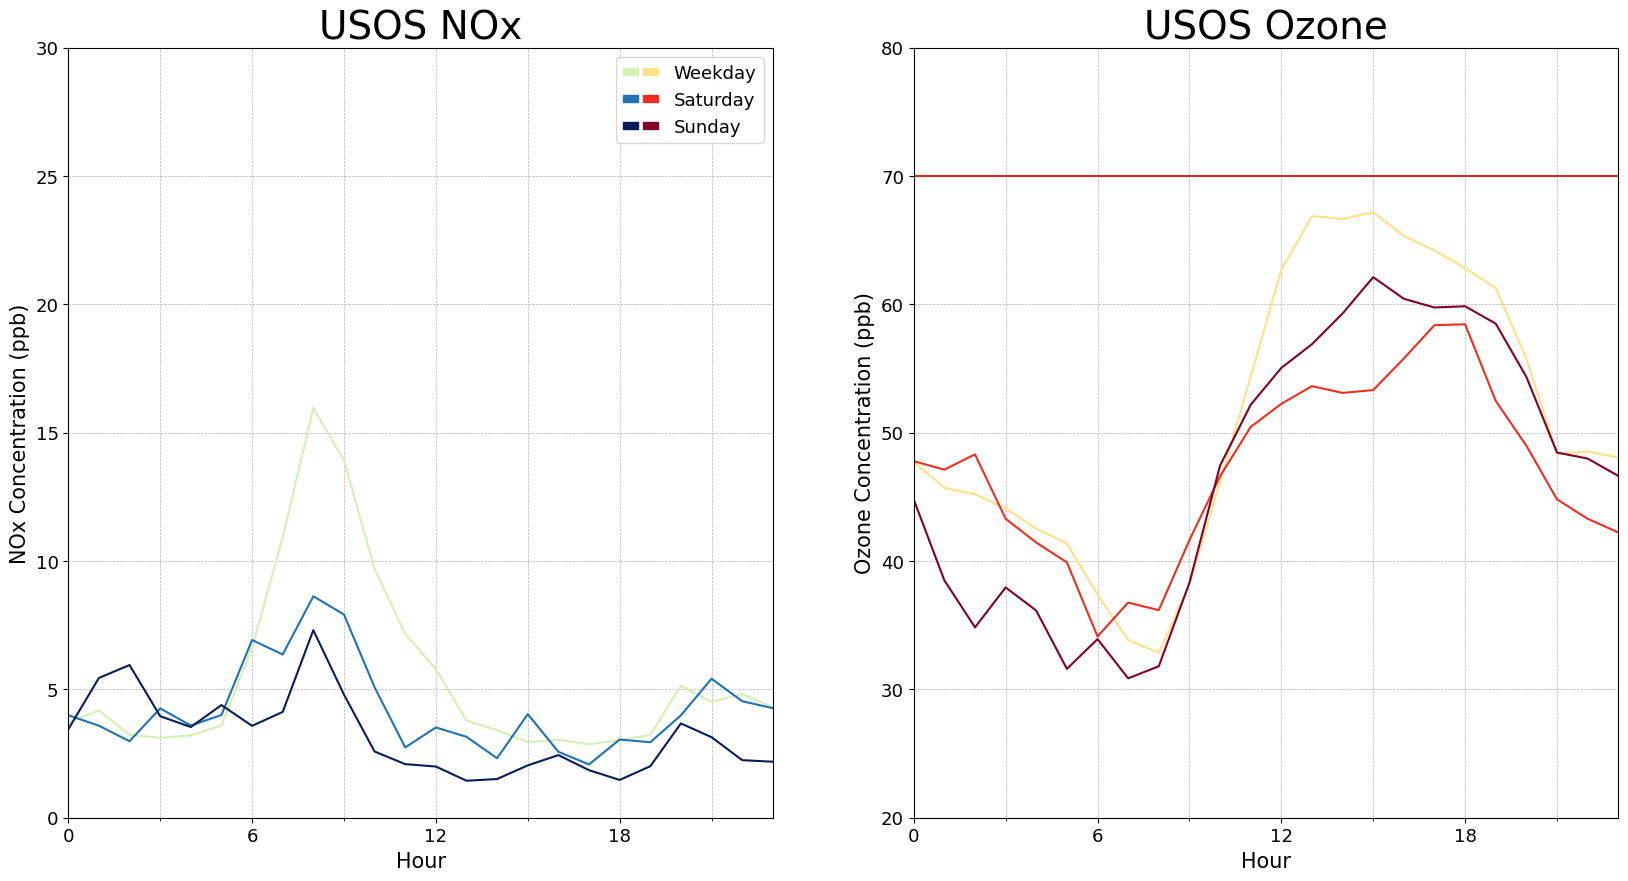

In [ ]:
fig, ax = plt.subplots(1,2, figsize = (20,10))

# Create 20 color values for gradient in the colormap
color_values_week = np.linspace(0.2, 1.2, 3)
color_map1 = 'YlGnBu'
color_map2 = 'YlOrRd'
cmap1 = mpl.colormaps[color_map1]
cmap2 = mpl.colormaps[color_map2]

class TwoColorHandler(HandlerBase):
       def create_artists(self, legend, orig_handle,
                       xdescent, ydescent, width, height, fontsize, trans):
        patch_width = width / 2.5  # width of each square
        patch_height = height * 0.6  # height of each square
        spacing = 4
        y = ydescent + (height - patch_height) / 2

        # Two colored rectangles side by side
        patch1 = mpatches.Rectangle((xdescent, y), patch_width, patch_height,
                                    facecolor=orig_handle[0], edgecolor=orig_handle[0], transform=trans)
        patch2 = mpatches.Rectangle((xdescent + patch_width + spacing, y), patch_width, patch_height,
                                    facecolor=orig_handle[1], edgecolor=orig_handle[1], transform=trans)

        return [patch1, patch2]
legend_handles = []
legend_labels = []

# for day_val in range(0,2):

ax[0].set_xlabel('Hour')
ax[0].set_ylabel(species_name1 + ' Concentration (ppb)')
ax[0].set_xticks(np.arange(0,24))
ax[0].set_ylim(y_limit1_weekend)
ax[0].set_title('USOS ' + species_name1)
ax[0].plot(hour_range, weekday_allspecies_mean['Weekday'], color=cmap1(color_values_week[0]), label = 'Weekday')
ax[0].plot(hour_range, day_of_week_allspecies_mean['Saturday'], color=cmap1(color_values_week[1]), label = 'Saturday')
ax[0].plot(hour_range, day_of_week_allspecies_mean['Sunday'], color=cmap1(color_values_week[2]), label = 'Sunday')

ax[1].plot(hour_range, weekday_ozone_mean['Weekday'], color=cmap2(color_values_week[0]), label = 'Weekday')
ax[1].plot(hour_range, day_of_week_ozone_mean['Saturday'], color=cmap2(color_values_week[1]), label = 'Saturday')
ax[1].plot(hour_range, day_of_week_ozone_mean['Sunday'], color=cmap2(color_values_week[2]), label = 'Sunday')
ax[1].set_xlabel('Hour')
ax[1].set_ylabel(species_name2 + ' Concentration (ppb)')
ax[1].set_ylim(y_limit2_weekend)
ax[1].set_title('USOS ' + species_name2)

# Create dummy handle with two colors

legend_handles.append((cmap1(color_values_week[0]), cmap2(color_values_week[0])))
legend_handles.append((cmap1(color_values_week[1]), cmap2(color_values_week[1])))
legend_handles.append((cmap1(color_values_week[2]), cmap2(color_values_week[2])))
legend_labels.append('Weekday')
legend_labels.append('Saturday')
legend_labels.append('Sunday')

# Add to legend
ax[0].legend(legend_handles, legend_labels, handler_map={tuple: TwoColorHandler()})

        # Create two small colored markers for one label

# ax[0].plot(hour_range, overall_nox_avg, color = 'k', label = 'Campaign Average')
# ax[0].fill_between(hour_range, overall_nox_avg - overall_nox_std, overall_nox_avg + overall_nox_std, color='k',alpha = 0.1)
ax[0].xaxis.set_minor_locator(MultipleLocator(3))
ax[0].xaxis.set_major_locator(MultipleLocator(6))
ax[0].grid(which='both', linestyle='--', linewidth=0.5)

# box = ax[0].get_position()
# ax[0].set_position([box.x0, box.y0, box.width * 0.8, box.height])
#ax[0].legend(loc='center left', bbox_to_anchor=(1, 0.5))

# ax[1].plot(hour_range, overall_ozone_avg, color = 'k', label = 'Campaign Average')
# ax[1].fill_between(hour_range, overall_ozone_avg_merged - overall_ozone_std_merged, overall_ozone_avg_merged + overall_ozone_std_merged, color='k',alpha = 0.1)
ax[1].xaxis.set_minor_locator(MultipleLocator(3))
ax[1].xaxis.set_major_locator(MultipleLocator(6))
ax[1].grid(which='both', linestyle='--', linewidth=0.5)
ax[1].hlines(y=70, xmin = 0, xmax = 23, color = 'tab:red')

In [ ]:
count = df_ozone[(df_ozone['Weekday'] == 'Weekday') & (df_ozone['Exceedance_day_merged_ozone'] == True)].shape[0]
print('Number of times the exceedances happened on weekdays: ', int(count/24))

Number of times the exceedances happened on weekdays:  10
